In [1]:
import os 
os.getcwd()

'c:\\Users\\gupta\\OneDrive\\Desktop\\project\\bike'

In [2]:
import pandas as pd

import numpy as np 
import matplotlib.pyplot as plt 
import seaborn as sns

In [3]:
df = pd.read_csv(r'C:\Users\gupta\OneDrive\Desktop\project\bike\Used_Bikes.csv') 
df.head() 

,bike_name,price,city,kms_driven,owner,age,power,brand
0,TVS Star City Plus Dual Tone 110cc,35000.0,Ahmedabad,17654.0,First Owner,3.0,110.0,TVS
1,Royal Enfield Classic 350cc,119900.0,Delhi,11000.0,First Owner,4.0,350.0,Royal Enfield
2,Triumph Daytona 675R,600000.0,Delhi,110.0,First Owner,8.0,675.0,Triumph
3,TVS Apache RTR 180cc,65000.0,Bangalore,16329.0,First Owner,4.0,180.0,TVS
4,Yamaha FZ S V 2.0 150cc-Ltd. Edition,80000.0,Bangalore,10000.0,First Owner,3.0,150.0,Yamaha


In [4]:
# target variable = Y dependent variable
# features x variables , independent var.

In [5]:
df.info()  

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32648 entries, 0 to 32647
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   bike_name   32648 non-null  object 
 1   price       32648 non-null  float64
 2   city        32648 non-null  object 
 3   kms_driven  32648 non-null  float64
 4   owner       32648 non-null  object 
 5   age         32648 non-null  float64
 6   power       32648 non-null  float64
 7   brand       32648 non-null  object 
dtypes: float64(4), object(4)
memory usage: 2.0+ MB


In [6]:
df.isnull().sum() 


bike_name     0
price         0
city          0
kms_driven    0
owner         0
age           0
power         0
brand         0
dtype: int64

Find the duplicated value and find the sum value of 

In [7]:
df.duplicated().sum()
 

np.int64(25324)

Find the shape of data set 

In [8]:
df.shape[0] - df.duplicated().sum()


np.int64(7324)

Drop duplicates values

In [9]:
df.drop_duplicates(inplace=True)  


In [10]:
df.shape


(7324, 8)

In [11]:
cat_col = df.select_dtypes(include='O')
cat_col.head()


,bike_name,city,owner,brand
0,TVS Star City Plus Dual Tone 110cc,Ahmedabad,First Owner,TVS
1,Royal Enfield Classic 350cc,Delhi,First Owner,Royal Enfield
2,Triumph Daytona 675R,Delhi,First Owner,Triumph
3,TVS Apache RTR 180cc,Bangalore,First Owner,TVS
4,Yamaha FZ S V 2.0 150cc-Ltd. Edition,Bangalore,First Owner,Yamaha


In [12]:
num_col = df.select_dtypes(exclude='O')
num_col.head() 

,price,kms_driven,age,power
0,35000.0,17654.0,3.0,110.0
1,119900.0,11000.0,4.0,350.0
2,600000.0,110.0,8.0,675.0
3,65000.0,16329.0,4.0,180.0
4,80000.0,10000.0,3.0,150.0


In [13]:
df['bike_name'].nunique() 

471

In [14]:
cat_col = cat_col.drop(['bike_name','city'],axis='columns')
cat_col.head()

,owner,brand
0,First Owner,TVS
1,First Owner,Royal Enfield
2,First Owner,Triumph
3,First Owner,TVS
4,First Owner,Yamaha


In [15]:
df['owner'].value_counts() # value count of owner feature 

owner
First Owner             6642
Second Owner             588
Third Owner               84
Fourth Owner Or More      10
Name: count, dtype: int64

In [16]:
pd.get_dummies(cat_col).astype('int')

,owner_First Owner,owner_Fourth Owner Or More,owner_Second Owner,owner_Third Owner,brand_BMW,brand_Bajaj,brand_Benelli,brand_Ducati,brand_Harley-Davidson,brand_Hero,...,brand_LML,brand_MV,brand_Mahindra,brand_Rajdoot,brand_Royal Enfield,brand_Suzuki,brand_TVS,brand_Triumph,brand_Yamaha,brand_Yezdi
0,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,1,0,0,0
1,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,1,0,0,0,0,0
2,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,1,0,0
3,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,1,0,0,0
4,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9362,1,0,0,0,0,0,0,0,0,1,...,0,0,0,0,0,0,0,0,0,0
9369,1,0,0,0,0,1,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
9370,1,0,0,0,0,0,0,0,1,0,...,0,0,0,0,0,0,0,0,0,0
9371,1,0,0,0,0,1,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [17]:
cat_col['owner'].value_counts()

owner
First Owner             6642
Second Owner             588
Third Owner               84
Fourth Owner Or More      10
Name: count, dtype: int64

In [18]:
dt = {"First Owner":1,"Second Owner":2,"Third Owner":3,"Fourth Owner Or More":4}
dt

{'First Owner': 1,
 'Second Owner': 2,
 'Third Owner': 3,
 'Fourth Owner Or More': 4}

In [19]:
cat_col['owner'] = cat_col['owner'].map(dt)

In [20]:
cat_col['owner'].value_counts() # mapped data 


owner
1    6642
2     588
3      84
4      10
Name: count, dtype: int64

In [21]:
{i:key for key , i in enumerate(list(cat_col['brand'].unique()))}


{'TVS': 0,
 'Royal Enfield': 1,
 'Triumph': 2,
 'Yamaha': 3,
 'Honda': 4,
 'Hero': 5,
 'Bajaj': 6,
 'Suzuki': 7,
 'Benelli': 8,
 'KTM': 9,
 'Mahindra': 10,
 'Kawasaki': 11,
 'Ducati': 12,
 'Hyosung': 13,
 'Harley-Davidson': 14,
 'Jawa': 15,
 'BMW': 16,
 'Indian': 17,
 'Rajdoot': 18,
 'LML': 19,
 'Yezdi': 20,
 'MV': 21,
 'Ideal': 22}

In [22]:
cat_col['brand'].nunique()


23

In [23]:
dt2 = {'TVS': 0,
 'Royal Enfield': 1,
 'Triumph': 2,
 'Yamaha': 3,
 'Honda': 4,
 'Hero': 5,
 'Bajaj': 6,
 'Suzuki': 7,
 'Benelli': 8,
 'KTM': 9,
 'Mahindra': 10,
 'Kawasaki': 11,
 'Ducati': 12,
 'Hyosung': 13,
 'Harley-Davidson': 14,
 'Jawa': 15,
 'BMW': 16,
 'Indian': 17,
 'Rajdoot': 18,
 'LML': 19,
 'Yezdi': 20,
 'MV': 21,
 'Ideal': 22}
dt2

{'TVS': 0,
 'Royal Enfield': 1,
 'Triumph': 2,
 'Yamaha': 3,
 'Honda': 4,
 'Hero': 5,
 'Bajaj': 6,
 'Suzuki': 7,
 'Benelli': 8,
 'KTM': 9,
 'Mahindra': 10,
 'Kawasaki': 11,
 'Ducati': 12,
 'Hyosung': 13,
 'Harley-Davidson': 14,
 'Jawa': 15,
 'BMW': 16,
 'Indian': 17,
 'Rajdoot': 18,
 'LML': 19,
 'Yezdi': 20,
 'MV': 21,
 'Ideal': 22}

Mapping of data 

In [24]:
cat_col['brand'] = cat_col['brand'].map(dt2)


In [25]:
cat_col


,owner,brand
0,1,0
1,1,1
2,1,2
3,1,0
4,1,3
...,...,...
9362,1,5
9369,1,6
9370,1,14
9371,1,6


In [26]:
complete_df = pd.concat([cat_col,num_col],axis=1)
complete_df.head()

,owner,brand,price,kms_driven,age,power
0,1,0,35000.0,17654.0,3.0,110.0
1,1,1,119900.0,11000.0,4.0,350.0
2,1,2,600000.0,110.0,8.0,675.0
3,1,0,65000.0,16329.0,4.0,180.0
4,1,3,80000.0,10000.0,3.0,150.0


Check the data types 

In [27]:
complete_df.dtypes


owner           int64
brand           int64
price         float64
kms_driven    float64
age           float64
power         float64
dtype: object

In [28]:
metrix = complete_df.corr()
metrix

,owner,brand,price,kms_driven,age,power
owner,1.000000,0.005844,-0.005188,0.062612,0.203151,0.043746
brand,0.005844,1.000000,0.288409,-0.036161,-0.030263,0.068647
price,-0.005188,0.288409,1.000000,-0.199951,-0.248752,0.807641
kms_driven,0.062612,-0.036161,-0.199951,1.000000,0.367518,-0.168295
age,0.203151,-0.030263,-0.248752,0.367518,1.000000,-0.164211
power,0.043746,0.068647,0.807641,-0.168295,-0.164211,1.000000


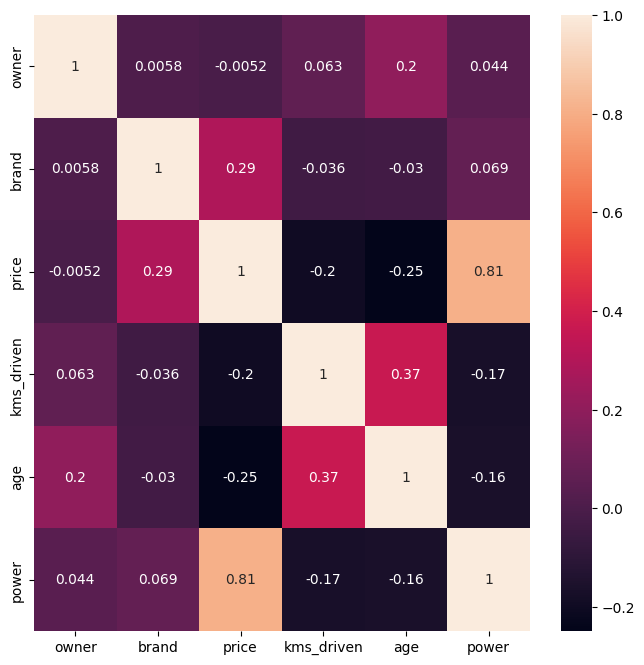

In [29]:
plt.figure(figsize=(8,8))
sns.heatmap(metrix,annot=True)
plt.show()

In [30]:
price = metrix['price']
price

owner        -0.005188
brand         0.288409
price         1.000000
kms_driven   -0.199951
age          -0.248752
power         0.807641
Name: price, dtype: float64

In [31]:
list(price[price<0.6].keys())

['owner', 'brand', 'kms_driven', 'age']

In [32]:
x = complete_df.drop('price',axis=1)
y = complete_df[['price']]

In [33]:
from sklearn.model_selection import train_test_split


In [34]:
x_train,x_test ,y_train,y_test = train_test_split(x,y,test_size=0.2,random_state=42)

In [35]:
x_train


,owner,brand,kms_driven,age,power
5789,1,0,68857.0,15.0,110.0
3451,1,1,5740.0,6.0,500.0
735,1,5,28329.0,6.0,110.0
7533,1,3,42966.0,7.0,150.0
8461,1,1,8000.0,5.0,500.0
...,...,...,...,...,...
6522,1,6,56000.0,9.0,200.0
6583,1,1,22493.0,5.0,500.0
6856,1,6,17477.0,5.0,150.0
1028,1,3,14836.0,8.0,150.0


Imports the LinearRegression class from the linear_model module within the sklearn (Scikit-learn) library.

In [36]:
from sklearn.linear_model import LinearRegression


Create obj of linearregression

In [37]:
lr = LinearRegression()


fit() function in machine learning libraries, such as Scikit-learn, is used to train a machine learning model on a given dataset.

In [38]:
lr.fit(x_train,y_train)


,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


score() function in Python is typically used in the context of machine learning models, especially those implemented in libraries like Scikit-learn. It's a method available for many supervised learning algorithms, such as regression, classification, and clustering.

In [39]:
lr.score(x_train,y_train)


0.7053826605671762

score() function in Python is typically used in the context of machine learning models, especially those implemented in libraries like Scikit-learn. It's a method available for many supervised learning algorithms, such as regression, classification, and clustering.

In [40]:
lr.score(x_test,y_test)


0.7586900869386048

predict() function predicts the class label (or probability) of new input data points based on the learned patterns from the training data

In [41]:
pred = lr.predict(x_test)


Create a feature in x_test data set 

In [42]:
y_test['prediction'] = pred


cheack of prediction and test value  

In [43]:
y_test


,price,prediction
4909,88400.0,125382.545235
1942,102850.0,216422.203336
5763,67000.0,96966.485952
4800,30000.0,7571.713344
7614,20000.0,8532.577046
...,...,...
5653,395000.0,476134.279312
609,140000.0,175120.608085
4211,54500.0,72233.836151
6379,114000.0,208856.676207


Find the mse and mae error

In [44]:
from sklearn.metrics import mean_squared_error,mean_absolute_error


This line of code calculates the mean squared error (MSE) between the actual target variable values (y_test['price']) and the predicted values (y_test['prediction']).

In [45]:
mean_squared_error(y_test['price'],y_test['prediction'])


4697994405.450356

In [46]:
# score 
# adjusted square
# correlation
# mean squared

Save of our model in file 
so we are import this library

In [47]:
import joblib, pickle


dump(that is used for save of file)

In [48]:
joblib.dump(lr,'linear-model.lb')


['linear-model.lb']

load(that is used of load of file)

In [49]:
model = joblib.load('linear-model.lb')


In [50]:
from sklearn.ensemble import RandomForestRegressor
rd = RandomForestRegressor()
rd.fit(x_train,y_train)


c:\Users\gupta\OneDrive\Desktop\project\bike_env\Lib\site-packages\sklearn\base.py:1365: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)


,n_estimators,100
,criterion,'squared_error'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,1.0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [51]:
y_test

,price,prediction
4909,88400.0,125382.545235
1942,102850.0,216422.203336
5763,67000.0,96966.485952
4800,30000.0,7571.713344
7614,20000.0,8532.577046
...,...,...
5653,395000.0,476134.279312
609,140000.0,175120.608085
4211,54500.0,72233.836151
6379,114000.0,208856.676207


In [52]:
print(rd.score(x_train,y_train))


0.9832668666645619


In [53]:
import joblib

In [54]:




joblib.dump(rd, 'model.lb')
joblib.dump(x.columns, 'model_columns.lb')


['model_columns.lb']

In [55]:
x_test

,owner,brand,kms_driven,age,power
4909,1,1,22500.0,6.0,350.0
1942,1,1,3198.0,5.0,500.0
5763,1,6,15000.0,6.0,220.0
4800,1,3,27000.0,12.0,150.0
7614,1,5,16764.0,9.0,100.0
...,...,...,...,...,...
5653,1,14,16523.0,5.0,750.0
609,1,13,2881.0,7.0,250.0
4211,1,7,23833.0,4.0,150.0
6379,1,1,9282.0,7.0,500.0


In [56]:
rd.predict([[1,1,22500.0,6.0,350.0]])

c:\Users\gupta\OneDrive\Desktop\project\bike_env\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(


array([109411.76190476])

In [57]:
model= joblib.load('model.lb') #load of file which is save in file 

In [58]:
# Model deployment

# Front and Backand  value accept 
                                                           
